# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [1]:
import pandas as pd
df_amn=pd.read_csv('df_amino15.csv', index_col='gene')
df_amn

,A,C,D,E,F,G,H,I,K,L,M,N,P,Q,R,S,T,V,W,Y
gene,,,,,,,,,,,,,,,,,,,,
GAB2,38,9,36,35,21,39,18,19,33,43,15,34,61,30,43,96,47,33,7,19
GRB2,12,2,18,14,17,15,6,9,16,14,5,13,11,11,12,11,5,14,5,7
LYN,31,8,34,39,20,33,7,32,46,43,13,15,28,21,26,29,26,28,9,24
PTGS1,25,13,24,36,39,45,18,25,25,74,18,19,46,27,33,33,30,32,10,27
FGFR3,66,17,47,53,24,68,20,22,37,80,17,22,56,26,44,61,43,71,11,21


In [2]:
def medidas(dados):
    
    serie = pd.Series(dados)
    
    media = serie.mean()
    mediana = serie.median()
    moda = serie.mode()
    
    return {
        'média': media,
        'mediana': mediana,
        'moda': moda.tolist()  
    }

#DE SERINA EM TODOS OS GENES
medidas(df_amn['S'])

{'média': np.float64(46.0),
 'mediana': np.float64(33.0),
 'moda': [11, 29, 33, 61, 96]}

In [3]:
#DO TERCEIRO GENE, PARA TODOS OS AMINOACIDOS
medidas(df_amn.iloc[2])

{'média': np.float64(25.6), 'mediana': np.float64(27.0), 'moda': [26, 28]}

## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [4]:
def amplitude(dados):
    serie = pd.Series(dados)
    return serie.max() - serie.min()

print(f'amplitude da isoleucina: ',{amplitude(df_amn['I'])})
print(f'amplitude do ultimo gene para todos os aas: ',{amplitude(df_amn.iloc[-1])})

amplitude da isoleucina:  {np.int64(23)}
amplitude do ultimo gene para todos os aas:  {np.int64(69)}


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [5]:
def calcular_quartis(dados):
    serie = pd.Series(dados)
    
    return {
        'Q1': serie.quantile(0.25),
        'Q2': serie.quantile(0.50),
        'Q3': serie.quantile(0.75)
    }

#metionina
print(calcular_quartis(df_amn['M']))

#primeiro gene
print(calcular_quartis(df_amn.iloc[0]))

{'Q1': np.float64(13.0), 'Q2': np.float64(15.0), 'Q3': np.float64(17.0)}
{'Q1': np.float64(19.0), 'Q2': np.float64(33.5), 'Q3': np.float64(40.0)}


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

In [6]:
def intervalo_interquartil(dados):
    serie = pd.Series(dados)
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    return q3 - q1

#DO ACIDO GLUTAMICO
print(intervalo_interquartil(df_amn['E']))

#DO PENULTIMO GENE
print(intervalo_interquartil(df_amn.iloc[-2]))

4.0
11.0


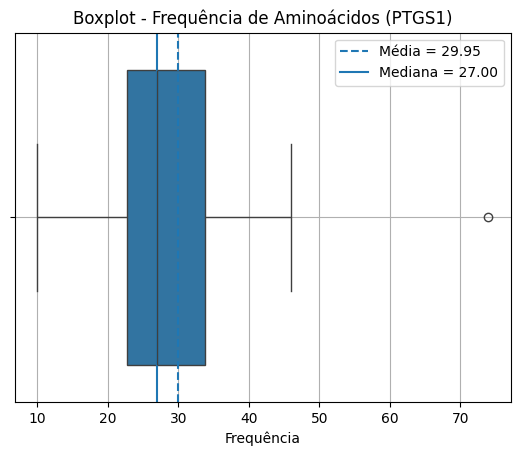

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

gene = df_amn.iloc[-2]  # penúltimo gene

media = gene.mean()
mediana = gene.median()

plt.figure()

sns.boxplot(x=gene)

# média (linha tracejada)
plt.axvline(media, linestyle='--', label=f'Média = {media:.2f}')

# mediana já aparece no boxplot, mas podemos reforçar
plt.axvline(mediana, linestyle='-', label=f'Mediana = {mediana:.2f}')

plt.title('Boxplot - Frequência de Aminoácidos (PTGS1)')
plt.xlabel('Frequência')
plt.legend()
plt.grid()

plt.show()

## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [8]:
import statistics as st
def variancia(dados):
    var=st.variance(df_amn['P'])
    return var

variancia(df_amn['P'])

429.3

In [9]:
def variancia_amostral(dados):
    serie = pd.Series(dados)
    return serie.var(ddof=1)

variancia_amostral(df_amn['P'])

np.float64(429.30000000000007)

## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [ ]:
def desv(dados):
    d=st.stdev(dados)
    return d

#triptofano
desv(df_amn.loc[:,'W'])

2.4083189157584592

In [21]:
#gene na posição -1 (FGFR3)
desv(df_amn.iloc[-1])

21.433127335235543

## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [25]:
def cv(dados):
    desvio=desv(dados)
    cv = str(round((desvio/st.mean(dados))*100, 2)) + "%"
    return cv

print(f'Coef de variação da leucina: ',cv(df_amn.loc[:,'L']))
print(f'Coef de variação do segundo gene: ',cv(df_amn.iloc[1]))

Coef de variação da leucina:  52.7%
Coef de variação do segundo gene:  41.89%


In [29]:
#alternativa 2:
def cv2(dados):
    return (dados.std(ddof=1) / dados.mean()) * 100

print(f'Coef de variação da leucina: {cv2(df_amn.loc[:, "L"]):.2f}%')
print(f'Coef de variação do segundo gene: {cv2(df_amn.iloc[1,:]):.2f}%')

Coef de variação da leucina: 52.70%
Coef de variação do segundo gene: 41.89%


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [44]:
def med_resumo(dados):
    dici = {
        'media': dados.mean(),
        'mediana': dados.median(),
        'moda': dados.mode().tolist(),  
        'quartis': calcular_quartis(dados),
        'intervalo interquartil': intervalo_interquartil(dados),
        'variancia': variancia(dados),
        'desvio padrao': desv(dados),
        'cv': cv(dados),
    }
    return dici

#exemplo>como dicionario ou convertendo em dataframe pandas:
resumo=med_resumo(df_amn.loc[:,'S'])
dfres=pd.DataFrame([resumo])
display(dfres)
display(resumo)

,media,mediana,moda,quartis,intervalo interquartil,variancia,desvio padrao,cv
0,46.0,33.0,"[11, 29, 33, 61, 96]","{'Q1': 29.0, 'Q2': 33.0, 'Q3': 61.0}",32.0,429.3,33.196385,72.166055


{'media': np.float64(46.0),
 'mediana': np.float64(33.0),
 'moda': [11, 29, 33, 61, 96],
 'quartis': {'Q1': np.float64(29.0),
  'Q2': np.float64(33.0),
  'Q3': np.float64(61.0)},
 'intervalo interquartil': np.float64(32.0),
 'variancia': 429.3,
 'desvio padrao': 33.19638534539566,
 'cv': np.float64(72.16605509868621)}

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

In [51]:
def gene_maior_cv(df):
    cvs = {}

    for idx in df.index: 
        cvs[idx] = cv(df.loc[idx, :])  

    gene_max = max(cvs, key=cvs.get)
    
    return gene_max, cvs[gene_max]

gene_maior_cv(df_amn)

('GAB2', np.float64(59.00474763248267))

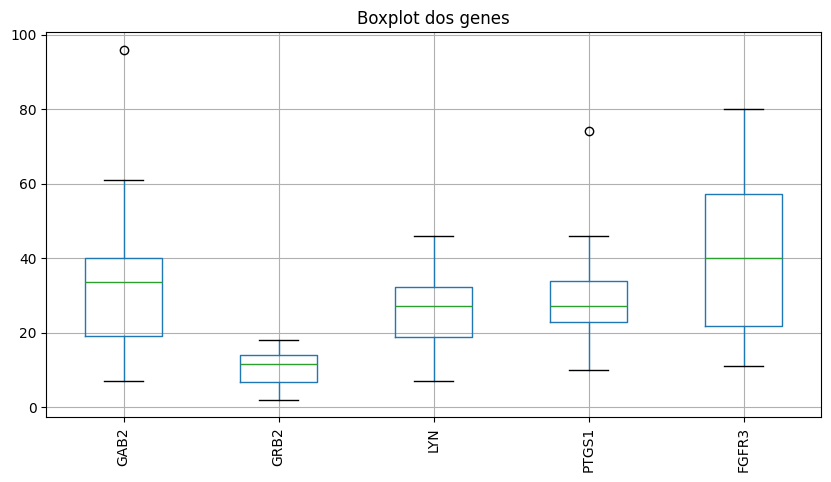

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_amn.T.boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot dos genes")
plt.show()

O coef de variação parte dos valores de media e desvio padrao para informar se a dispersão dos dados em relação a media é grande ou pequena. Ou seja, dados com o mesmo desvio padrao podem ter coeficiente de variação distintos.

Entao, quanto maior o CV, maior essa dispersao em relação a media e isso é refletido em um boxplot mais espalhado.

No caso do exercício, os dados de valor de cv e o boxplot concordam, sendo que para o GAB2 tem um outlier que faz aumentar essa dispersão (cv é sensível a outliers devido ao calculo em que se baseia), ainda que o coef de variação do FGFR3 seja muito proximo, mas nao tem um outlier 'puxando' esses dados.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

In [55]:
def aa_maior_cv(df):
    cvs = {}

    for i in df.columns:
        cvs[i] = round(cv(df[i]), 3)

    aa_max = max(cvs, key=cvs.get)
    
    return aa_max, cvs[aa_max], cvs

aa_maior_cv(df_amn)

('S',
 np.float64(72.166),
 {'A': np.float64(58.379),
  'C': np.float64(57.452),
  'D': np.float64(35.327),
  'E': np.float64(39.477),
  'F': np.float64(35.715),
  'G': np.float64(48.153),
  'H': np.float64(48.718),
  'I': np.float64(39.458),
  'K': np.float64(36.492),
  'L': np.float64(52.699),
  'M': np.float64(38.065),
  'N': np.float64(40.118),
  'P': np.float64(51.286),
  'Q': np.float64(32.391),
  'R': np.float64(41.899),
  'S': np.float64(72.166),
  'T': np.float64(54.881),
  'V': np.float64(59.541),
  'W': np.float64(28.67),
  'Y': np.float64(39.123)})

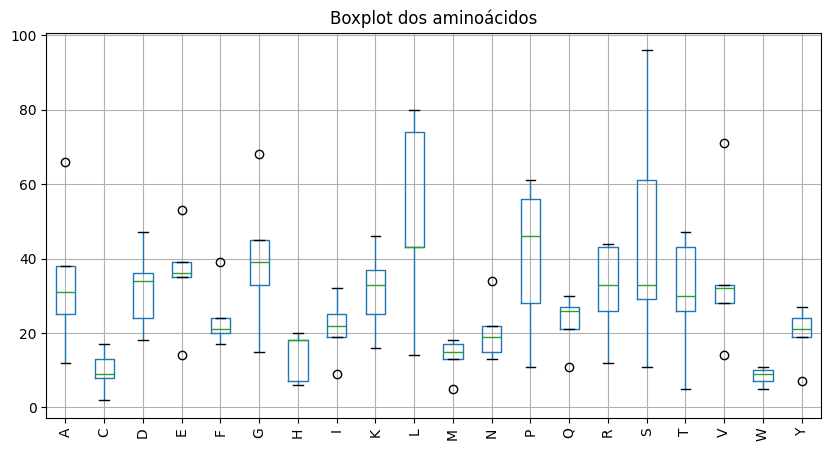

In [56]:
plt.figure(figsize=(10,5))
df_amn.boxplot()
plt.xticks(rotation=90)
plt.title("Boxplot dos aminoácidos")
plt.show()

Nesse caso os dados concordam nitidamente, uma vez que o boxplot para a serina (indicada como maior cv) é o mais espalhado entre todos